In [2]:
import itertools
from fractions import Fraction
from collections import Counter
import random
import bisect


def get_numbers_for_triplet(triplet, memo):
    def dfs(nums):
        if nums in memo:
            return memo[nums]
        if len(nums) == 1:
            return {nums[0]}

        res = set()
        n = len(nums)
        for i in range(1, (1 << n) - 1):
            left_nums = []
            right_nums = []
            for j in range(n):
                if (i & (1 << j)):
                    left_nums.append(nums[j])
                else:
                    right_nums.append(nums[j])

            left_nums = tuple(sorted(left_nums))
            right_nums = tuple(sorted(right_nums))

            left_results = dfs(left_nums)
            right_results = dfs(right_nums)

            for l in left_results:
                for r in right_results:
                    res.add(l + r)
                    res.add(l - r)
                    res.add(l * r)
                    if r != 0:
                        res.add(l / r)

        memo[nums] = res
        return res

    fraction_nums = tuple(sorted([Fraction(x) for x in triplet]))
    all_values = dfs(fraction_nums)
    return {v.numerator for v in all_values if v.denominator == 1}

In [3]:
# ── Configuration ──────────────────────────────────────────────────
# Target range 1-60, multipliers tuned for EV ≈ 1.05x
#
#   Exact hit  → 1.75x    (P ≈ 26.9%)
#   Within ±2  → 1.25x    (P ≈ 40.4%)
#   Within ±4  → 0.50x    (P ≈ 15.0%)
#   Miss       → 0.00x    (P ≈ 17.7%)
#
#   EV = 0.269×1.75 + 0.404×1.25 + 0.150×0.50 ≈ 1.05x
# ──────────────────────────────────────────────────────────────────

MAX_TARGET = 60           # targets drawn from 1 … 60

MULT_EXACT = 1.75         # hit the number exactly
MULT_CLOSE = 1.25         # within ±2
MULT_NEAR  = 0.50         # within ±4
MULT_MISS  = 0.00         # further than ±4


def build_frequency_table():
    all_hands = list(itertools.combinations_with_replacement(range(1, 14), 3))
    freq = Counter()
    memo = {}
    for hand in all_hands:
        for num in get_numbers_for_triplet(hand, memo):
            freq[num] += 1
    return {k: v for k, v in freq.items() if 1 <= k <= MAX_TARGET}

FREQ_TABLE = build_frequency_table()
_numbers = sorted(FREQ_TABLE.keys())
_weights = [FREQ_TABLE[n] for n in _numbers]
_total = sum(_weights)
_cdf = []
_acc = 0.0
for w in _weights:
    _acc += w / _total
    _cdf.append(_acc)

In [4]:
def generate_target() -> int:
    r = random.random()
    idx = bisect.bisect_left(_cdf, r)
    return _numbers[min(idx, len(_numbers) - 1)]

In [5]:
def get_payout_mult(target: int, guess: int) -> tuple[str, float]:
    """Return (tier_name, multiplier) for a guess against the target."""
    diff = abs(target - guess)
    if diff == 0:
        return ("exact", MULT_EXACT)
    elif diff <= 2:
        return ("close", MULT_CLOSE)
    elif diff <= 4:
        return ("near", MULT_NEAR)
    else:
        return ("miss", MULT_MISS)

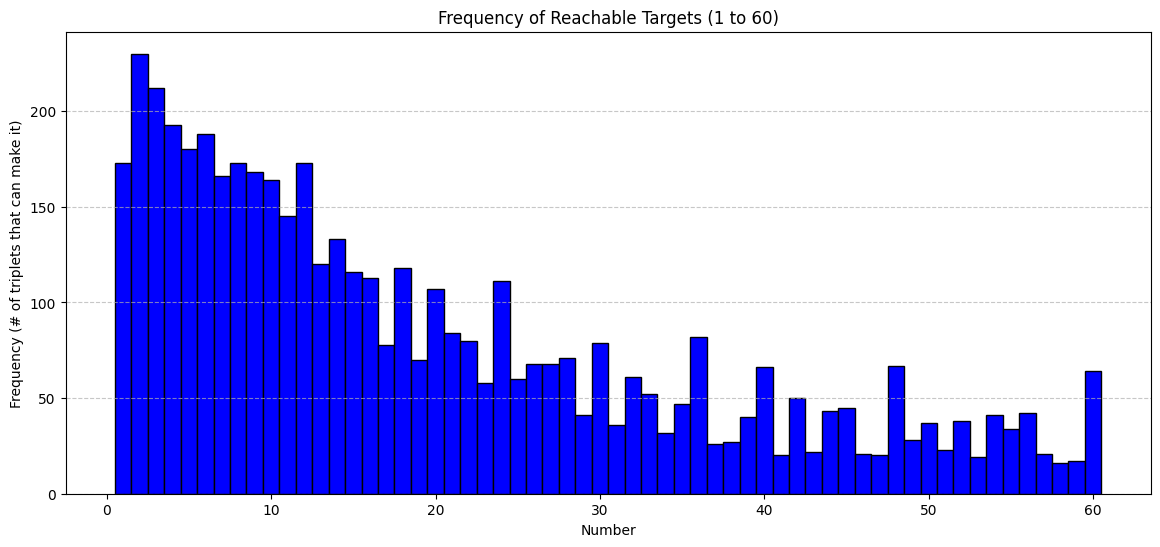

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(_numbers, _weights, color='blue', edgecolor='black', width=1.0)
plt.title(f'Frequency of Reachable Targets (1 to {MAX_TARGET})')
plt.xlabel('Number')
plt.ylabel('Frequency (# of triplets that can make it)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

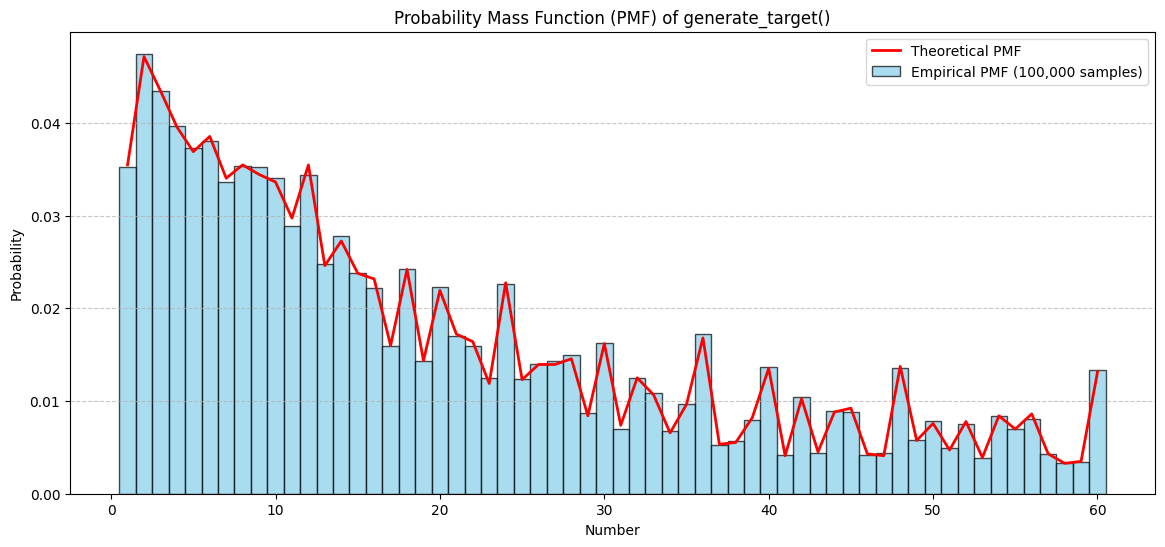

In [7]:
num_samples = 100_000
samples = [generate_target() for _ in range(num_samples)]

sample_counts = Counter(samples)
sim_numbers = sorted(sample_counts.keys())
sim_pmf = [sample_counts[n] / num_samples for n in sim_numbers]

theoretical_pmf = [w / _total for w in _weights]

plt.figure(figsize=(14, 6))
plt.bar(sim_numbers, sim_pmf, color='skyblue', edgecolor='black', alpha=0.7,
        label=f'Empirical PMF ({num_samples:,} samples)', width=1.0)
plt.plot(_numbers, theoretical_pmf, color='red', linestyle='-', linewidth=2,
         label='Theoretical PMF')
plt.title('Probability Mass Function (PMF) of generate_target()')
plt.xlabel('Number')
plt.ylabel('Probability')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
# ── EV Verification (Monte Carlo) ─────────────────────────────────

all_hands = list(itertools.combinations_with_replacement(range(1, 14), 3))
memo = {}
_hand_reachable = {}
for hand in all_hands:
    _hand_reachable[hand] = get_numbers_for_triplet(hand, memo)

def optimal_payout(target, hand):
    """Best possible payout for a hand against a target (assumes perfect play)."""
    reachable = _hand_reachable[hand]
    best_mult = MULT_MISS
    for r in reachable:
        if r < 1:
            continue
        _, m = get_payout_mult(target, r)
        if m > best_mult:
            best_mult = m
            if best_mult == MULT_EXACT:
                break
    return best_mult

N = 200_000
total_return = 0.0
for _ in range(N):
    t = generate_target()
    h = all_hands[random.randint(0, len(all_hands) - 1)]
    total_return += optimal_payout(t, h)

simulated_ev = total_return / N
print(f"Monte Carlo EV ({N:,} rounds): {simulated_ev:.4f}x")
print(f"Target EV:                      1.0500x")
print(f"Difference:                     {abs(simulated_ev - 1.05):.4f}")

Monte Carlo EV (200,000 rounds): 1.0504x
Target EV:                      1.0500x
Difference:                     0.0004


In [9]:
if __name__ == "__main__":
    t = generate_target()
    tier, mult = get_payout_mult(t, t)
    print(f"Target: {t:>3}")

Target:  11
